# Austin Ionosonde Data Analysis - Figure 8

This notebook loads ionosonde data from the Austin, TX ionosonde (AU930) and visualizes the major ionospheric parameters.

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import hf_tdoa as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Load Ionosonde Data from Excel

The Excel file contains separate sheets for each ionospheric parameter:
- hmF2, hmF1, hmE: Virtual heights of the F2, F1, and E layers (km)
- foF2, foF1, foE: Critical frequencies of the F2, F1, and E layers (MHz)

Each sheet contains the parameter value and its confidence score (CS).

In [ ]:
# Path to the Excel file
excel_path = '20240408_AU930_Austin_TX_GIRO_DIDB.xlsx'

# Load the Excel file
xls = pd.ExcelFile(excel_path)

print(f"Available sheets: {xls.sheet_names}")

# Load header information
header_df = pd.read_excel(xls, sheet_name='header')
print(f"\nHeader information loaded: {header_df.shape[0]} lines")

# Parameters to load (skip the 'header' sheet)
parameters = ['hmF2', 'hmF1', 'hmE', 'foF2', 'foF1', 'foE']

# Dictionary to store individual DataFrames
param_dfs = {}

# Load each parameter sheet
for param in parameters:
    df = pd.read_excel(xls, sheet_name=param)
    param_dfs[param] = df
    print(f"\nLoaded {param}: {df.shape[0]} records")
    print(f"  Columns: {df.columns.tolist()}")

Available sheets: ['header', 'hmF2', 'hmF1', 'hmE', 'foF2', 'foF1', 'foE']

Header information loaded: 16 lines

Loaded hmF2: 286 records
  Columns: ['Date', 'UTC', 'hmF2_CS', 'hmF2']

Loaded hmF1: 73 records
  Columns: ['Date', 'UTC', 'hmF1_CS', 'hmF1']

Loaded hmE: 288 records
  Columns: ['Date', 'UTC', 'hmE_CS', 'hmE']

Loaded foF2: 288 records
  Columns: ['Date', 'UTC', 'foF2_CS', 'foF2']

Loaded foF1: 75 records
  Columns: ['Date', 'UTC', 'foF1_CS', 'foF1']

Loaded foE: 104 records
  Columns: ['Date', 'UTC', 'foE_CS', 'foE']


## Create Unified DataFrame

Merge all parameters into a single DataFrame with a proper datetime index.

In [3]:
# Start with the first parameter (hmF2) as the base
base_df = param_dfs['hmF2'].copy()

# Create datetime column by combining Date and UTC
base_df['DateTime'] = pd.to_datetime(base_df['Date'].astype(str) + ' ' + base_df['UTC'].astype(str))

# Keep only DateTime and the hmF2 columns
unified_df = base_df[['DateTime', 'hmF2', 'hmF2_CS']].copy()

# Set DateTime as index
unified_df = unified_df.set_index('DateTime')

# Add other parameters by merging on the datetime index
for param in ['hmF1', 'hmE', 'foF2', 'foF1', 'foE']:
    df = param_dfs[param].copy()
    
    # Create datetime column
    df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['UTC'].astype(str))
    
    # Keep only the parameter and confidence score columns
    param_cols = ['DateTime', param, f'{param}_CS']
    df_temp = df[param_cols].set_index('DateTime')
    
    # Merge with unified DataFrame
    unified_df = unified_df.join(df_temp, how='outer')

# Sort by datetime index
unified_df = unified_df.sort_index()

print(f"\nUnified DataFrame shape: {unified_df.shape}")
print(f"\nColumns: {unified_df.columns.tolist()}")
print(f"\nDate range: {unified_df.index.min()} to {unified_df.index.max()}")
print(f"\nFirst few rows:")
display(unified_df.head())

print(f"\nData summary:")
display(unified_df.describe())


Unified DataFrame shape: (289, 12)

Columns: ['hmF2', 'hmF2_CS', 'hmF1', 'hmF1_CS', 'hmE', 'hmE_CS', 'foF2', 'foF2_CS', 'foF1', 'foF1_CS', 'foE', 'foE_CS']

Date range: 2024-04-08 00:00:00 to 2024-04-08 23:55:00

First few rows:


,hmF2,hmF2_CS,hmF1,hmF1_CS,hmE,hmE_CS,foF2,foF2_CS,foF1,foF1_CS,foE,foE_CS
DateTime,,,,,,,,,,,,
2024-04-08 00:00:00,267.3,50.0,NaN,NaN,110.0,50.0,10.60,50.0,NaN,NaN,NaN,NaN
2024-04-08 00:05:00,278.4,100.0,NaN,NaN,89.9,100.0,11.35,100.0,NaN,NaN,2.22,100.0
2024-04-08 00:10:00,260.0,100.0,NaN,NaN,110.0,100.0,10.35,100.0,NaN,NaN,NaN,NaN
2024-04-08 00:15:00,278.0,100.0,NaN,NaN,110.0,100.0,11.30,100.0,NaN,NaN,2.32,100.0
2024-04-08 00:20:00,272.0,100.0,NaN,NaN,110.0,100.0,11.30,100.0,NaN,NaN,NaN,NaN



Data summary:


,hmF2,hmF2_CS,hmF1,hmF1_CS,hmE,hmE_CS,foF2,foF2_CS,foF1,foF1_CS,foE,foE_CS
count,286.000000,286.000000,73.000000,73.000000,152.000000,288.000000,288.000000,288.000000,75.000000,75.000000,103.000000,103.000000
mean,294.795455,96.538462,166.568493,94.657534,104.488158,95.868056,8.096726,95.868056,4.932133,92.133333,3.056893,91.941748
std,39.047529,12.178940,10.644050,11.556887,8.057582,14.552918,2.209487,14.552918,0.452504,19.122177,0.577858,19.855273
min,215.900000,0.000000,136.400000,70.000000,85.700000,0.000000,3.700000,0.000000,3.050000,0.000000,1.320000,0.000000
25%,265.600000,100.000000,160.900000,100.000000,98.100000,100.000000,5.700000,100.000000,4.680000,100.000000,2.770000,100.000000
50%,280.150000,100.000000,165.600000,100.000000,107.800000,100.000000,8.800000,100.000000,5.010000,100.000000,3.220000,100.000000
75%,331.250000,100.000000,174.200000,100.000000,110.000000,100.000000,10.250000,100.000000,5.250000,100.000000,3.420000,100.000000
max,375.500000,100.000000,194.000000,100.000000,123.300000,100.000000,11.350000,100.000000,5.600000,100.000000,3.920000,100.000000


## Plot Virtual Heights

Plot hmF2, hmF1, and hmE (virtual heights of ionospheric layers).

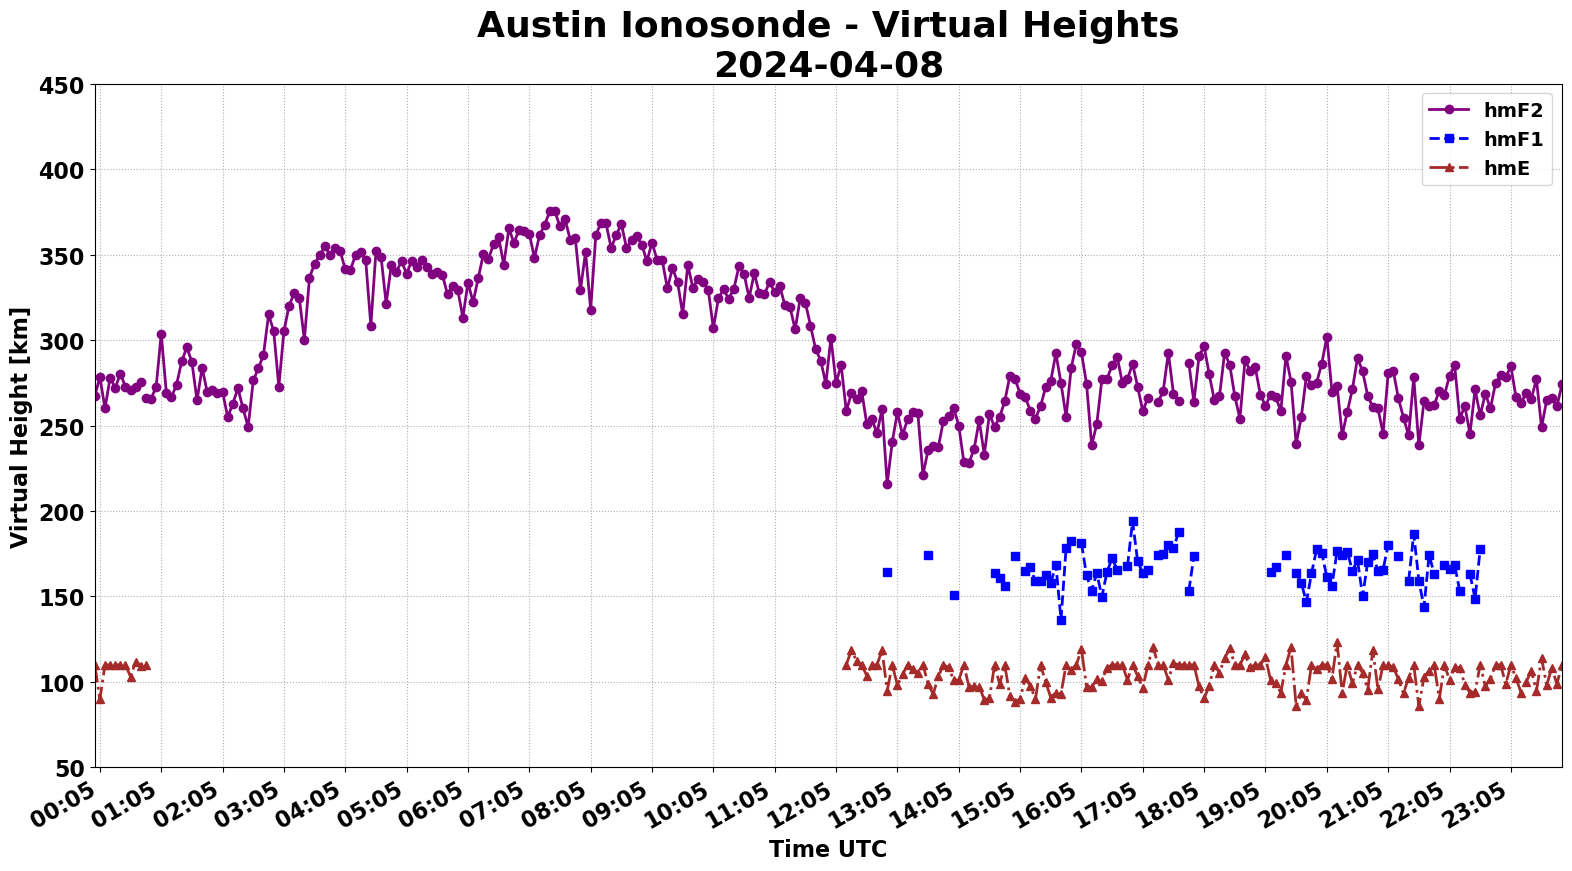

In [4]:
fig, ax = plt.subplots(figsize=(16, 9))

# Plot virtual heights
ax.plot(unified_df.index, unified_df['hmF2'], 
        label='hmF2', marker='o', linestyle='-', linewidth=2, color='purple')
ax.plot(unified_df.index, unified_df['hmF1'], 
        label='hmF1', marker='s', linestyle='--', linewidth=2, color='blue')
ax.plot(unified_df.index, unified_df['hmE'], 
        label='hmE', marker='^', linestyle='-.', linewidth=2, color='brown')

# Format the plot
ax.set_xlabel('Time UTC')
ax.set_ylabel('Virtual Height [km]')
ax.set_title('Austin Ionosonde - Virtual Heights\n2024-04-08', fontsize=26)
ax.legend(loc='best', fontsize=14)
ax.set_ylim(50, 450)

# Format datetime axis
import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(myFmt)
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## Plot Critical Frequencies

Plot foF2, foF1, and foE (critical frequencies of ionospheric layers).

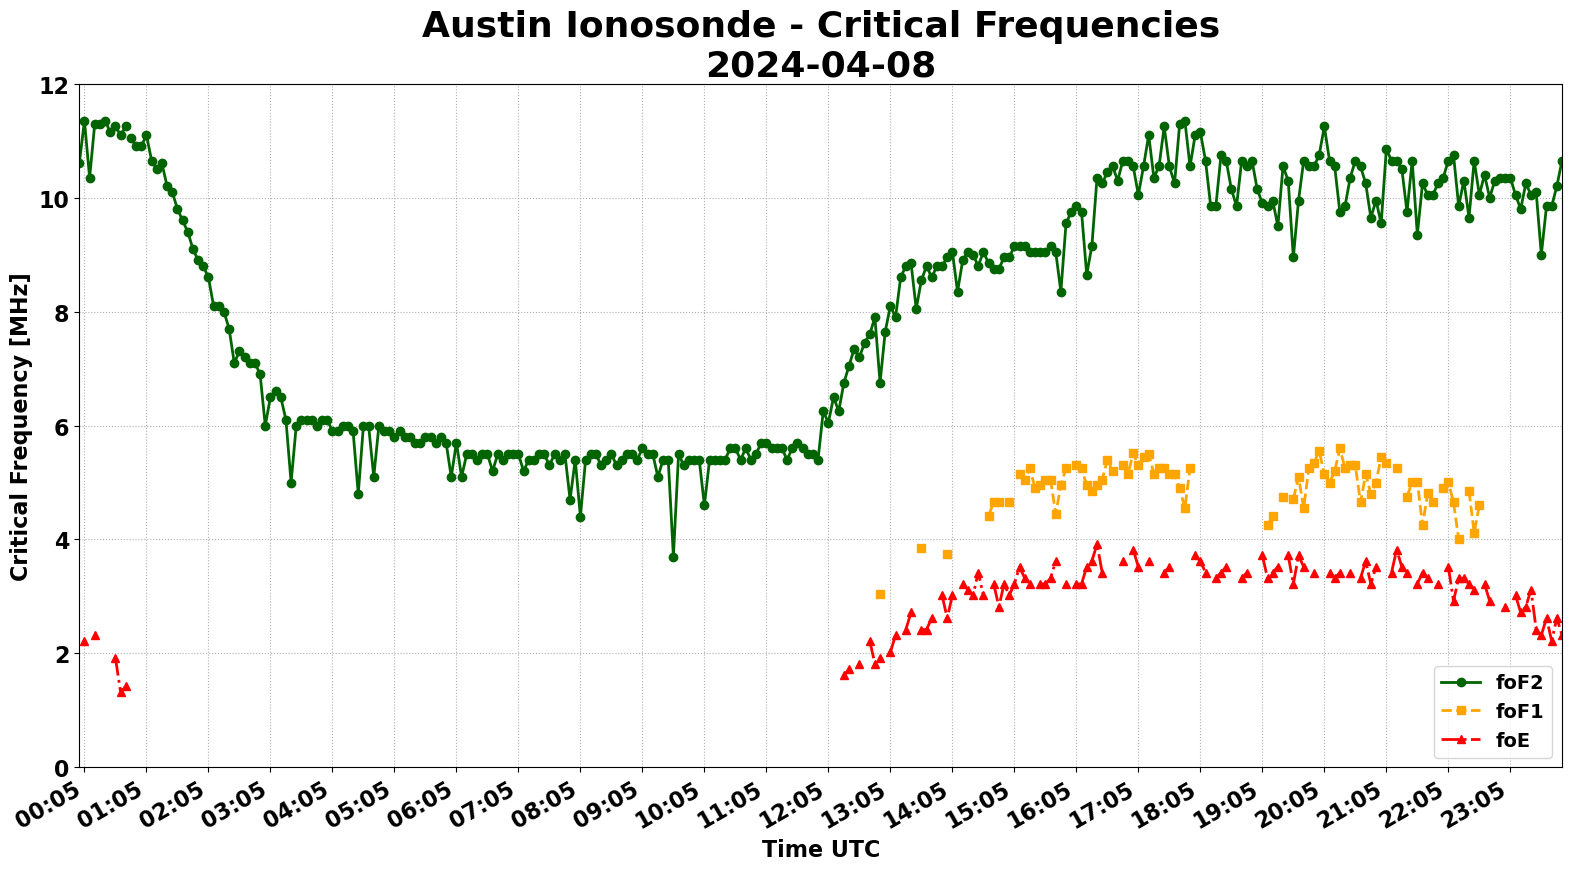

In [5]:
fig, ax = plt.subplots(figsize=(16, 9))

# Plot critical frequencies
ax.plot(unified_df.index, unified_df['foF2'], 
        label='foF2', marker='o', linestyle='-', linewidth=2, color='darkgreen')
ax.plot(unified_df.index, unified_df['foF1'], 
        label='foF1', marker='s', linestyle='--', linewidth=2, color='orange')
ax.plot(unified_df.index, unified_df['foE'], 
        label='foE', marker='^', linestyle='-.', linewidth=2, color='red')

# Format the plot
ax.set_xlabel('Time UTC')
ax.set_ylabel('Critical Frequency [MHz]')
ax.set_title('Austin Ionosonde - Critical Frequencies\n2024-04-08', fontsize=26)
ax.legend(loc='best', fontsize=14)
ax.set_ylim(0, 12)

# Format datetime axis
import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(myFmt)
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## Export to CSV

Save the unified DataFrame to a CSV file for later reuse.

In [ ]:
# Define output CSV path
csv_output_path = '20240408_AU930_Austin_TX_GIRO_DIDB.csv'

# Write header information as comments, then append the DataFrame
with open(csv_output_path, 'w') as f:
    # Write header lines as comments
    for idx, row in header_df.iterrows():
        # Get the first column value (header text)
        header_text = str(row.iloc[0]).strip()
        # Header lines already start with #, so just write them directly
        f.write(f"{header_text}\n")
    
    # Add a separator line
    f.write("#\n")

# Append the DataFrame to the file
unified_df.to_csv(csv_output_path, mode='a')

print(f"Unified DataFrame saved to: {csv_output_path}")
print(f"File size: {os.path.getsize(csv_output_path) / 1024:.2f} KB")
print(f"\nHeader lines from Excel included as comments at the top of the CSV.")
print(f"\nTo reload this data later, use:")
print(f"  df = pd.read_csv('{csv_output_path}', comment='#', index_col='DateTime', parse_dates=True)")

Unified DataFrame saved to: 20240408_AU930_Austin_Unified.csv
File size: 19.30 KB

Header lines from Excel included as comments at the top of the CSV.

To reload this data later, use:
  df = pd.read_csv('20240408_AU930_Austin_Unified.csv', comment='#', index_col='DateTime', parse_dates=True)


## Test CSV Reload

Verify that the CSV file can be loaded correctly.

In [7]:
# Reload the CSV to verify it works
# Note: comment='#' tells pandas to skip lines starting with #
reloaded_df = pd.read_csv(csv_output_path, comment='#', index_col='DateTime', parse_dates=True)

print(f"Reloaded DataFrame shape: {reloaded_df.shape}")
print(f"\nFirst few rows:")
display(reloaded_df.head())

# Verify data integrity
assert unified_df.shape == reloaded_df.shape, "Shape mismatch!"
print("\n✓ CSV reload successful - data integrity verified!")
print("✓ Header comments properly skipped during reload")

Reloaded DataFrame shape: (289, 12)

First few rows:


,hmF2,hmF2_CS,hmF1,hmF1_CS,hmE,hmE_CS,foF2,foF2_CS,foF1,foF1_CS,foE,foE_CS
DateTime,,,,,,,,,,,,
2024-04-08 00:00:00,267.3,50.0,NaN,NaN,110.0,50.0,10.60,50.0,NaN,NaN,NaN,NaN
2024-04-08 00:05:00,278.4,100.0,NaN,NaN,89.9,100.0,11.35,100.0,NaN,NaN,2.22,100.0
2024-04-08 00:10:00,260.0,100.0,NaN,NaN,110.0,100.0,10.35,100.0,NaN,NaN,NaN,NaN
2024-04-08 00:15:00,278.0,100.0,NaN,NaN,110.0,100.0,11.30,100.0,NaN,NaN,2.32,100.0
2024-04-08 00:20:00,272.0,100.0,NaN,NaN,110.0,100.0,11.30,100.0,NaN,NaN,NaN,NaN



✓ CSV reload successful - data integrity verified!
✓ Header comments properly skipped during reload
